In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 45.9MB/s]



In [5]:
!unzip breast-cancer-wisconsin-data.zip

Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                


In [62]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [63]:
x =df.drop(columns=['id', 'diagnosis']).values

In [64]:
y = df['diagnosis'].values

In [65]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.25, random_state=2)

In [66]:
mask = ~np.isnan(xtrain).all(axis=0)
xtrain = xtrain[:, mask]
xtest = xtest[:, mask]

In [67]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

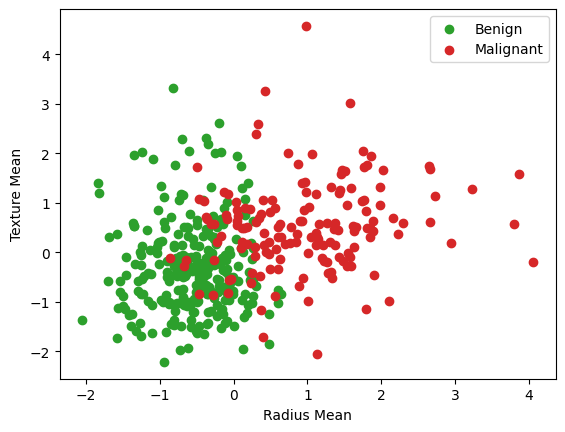

In [68]:
plt.scatter(xtrain[ytrain == 'B', 0], xtrain[ytrain == 'B', 1], color='tab:green', label='Benign')
plt.scatter(xtrain[ytrain == 'M', 0], xtrain[ytrain == 'M', 1], color='tab:red', label='Malignant')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend()
plt.show()


In [69]:
def distance(a,b):
  return np.sqrt(np.sum((b-a)**2))

In [70]:
class KNN:
  def __init__(self, k):
    self.k = k

  def fit(self, x,y):
    self.xtrain = x
    self.ytrain = y


  def predict(self, new_points):
    predictions = [self.predict_class(new_point) for new_point in new_points]
    return np.array(predictions)


  def predict_class(self, new_point):
    dist = [distance(point, new_point) for point in self.xtrain]

    k_n_indice = np.argsort(dist)[:self.k]
    k_n_labels = [self.ytrain[i] for i in k_n_indice]
    most_common = Counter(k_n_labels).most_common(1)[0][0]
    return most_common

In [71]:
knn = KNN(2)
knn.fit(xtrain,ytrain)
preds = knn.predict(xtest)

In [72]:
accuracy = np.mean(preds == ytest) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 93.71%


k= 1 | train_acc=100.00% | test_acc= 93.71% | pred_dist={np.str_('B'): 84, np.str_('M'): 59}
k= 2 | train_acc=100.00% | test_acc= 93.71% | pred_dist={np.str_('B'): 84, np.str_('M'): 59}
k= 3 | train_acc= 97.65% | test_acc= 98.60% | pred_dist={np.str_('B'): 89, np.str_('M'): 54}
k= 4 | train_acc= 98.36% | test_acc= 97.90% | pred_dist={np.str_('B'): 90, np.str_('M'): 53}
k= 5 | train_acc= 97.42% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k= 6 | train_acc= 97.89% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k= 7 | train_acc= 97.18% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k= 8 | train_acc= 97.65% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k= 9 | train_acc= 97.42% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k=10 | train_acc= 97.65% | test_acc= 97.20% | pred_dist={np.str_('B'): 91, np.str_('M'): 52}
k=11 | train_acc= 97.42% | test_acc= 97.20% | pred_dist={np.str_('B'):

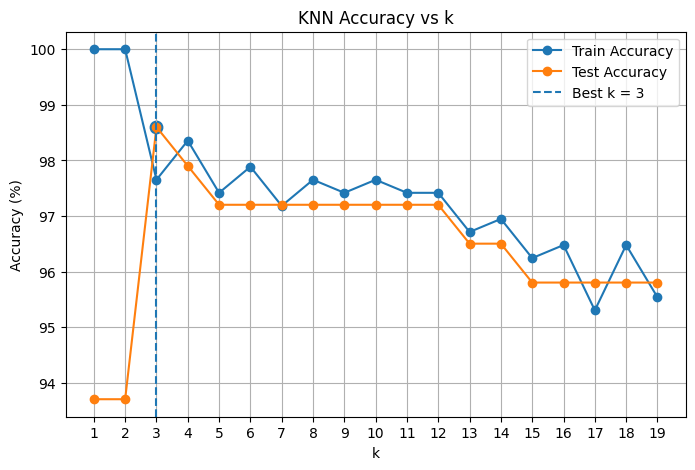

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

all_preds = {}
test_accs = []
train_accs = []

ks = np.arange(1, 20)

for k in ks:
    knn = KNN(k)
    knn.fit(xtrain, ytrain)

    train_preds = knn.predict(xtrain)
    test_preds = knn.predict(xtest)

    all_preds[k] = test_preds

    train_acc = np.mean(train_preds == ytrain) * 100
    test_acc = np.mean(test_preds == ytest) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"k={k:2d} | "
        f"train_acc={train_acc:6.2f}% | "
        f"test_acc={test_acc:6.2f}% | "
        f"pred_dist={dict(Counter(test_preds))}"
    )

best_idx = np.argmax(test_accs)
best_k = ks[best_idx]
best_test_acc = test_accs[best_idx]

print("\nBest k:", best_k)
print(f"Best test accuracy: {best_test_acc:.2f}%")

if 1 in all_preds and 11 in all_preds:
    print("k=1 vs k=11 identical:", np.array_equal(all_preds[1], all_preds[11]))

# how many unique prediction patterns across k
unique_prediction_patterns = len({tuple(all_preds[k]) for k in ks})
print("Unique prediction patterns across k:", unique_prediction_patterns)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ks, train_accs, marker='o', label='Train Accuracy')
plt.plot(ks, test_accs, marker='o', label='Test Accuracy')

plt.axvline(best_k, linestyle='--', label=f'Best k = {best_k}')
plt.scatter(best_k, best_test_acc, s=80)

plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs k")
plt.xticks(ks)
plt.grid(True)
plt.legend()
plt.show()